<a href="https://colab.research.google.com/github/kylekorver11/Student-Performance-Prediction-and-Learning-Pattern-Analysis/blob/main/netflix_churn_analysis...ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

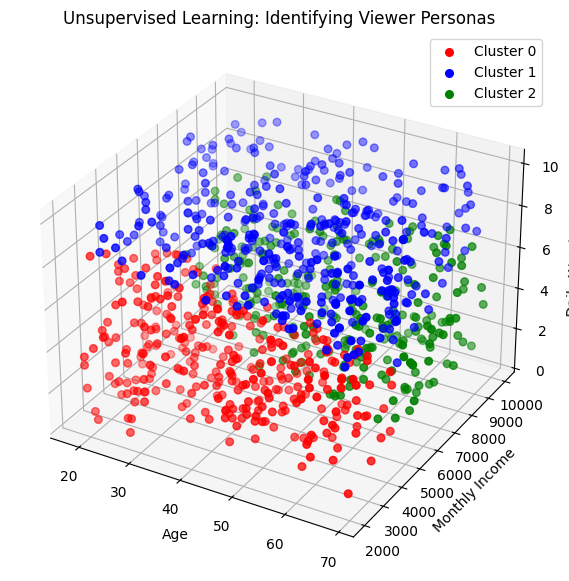

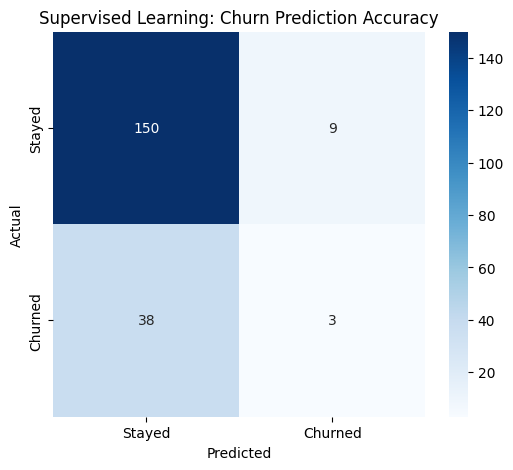

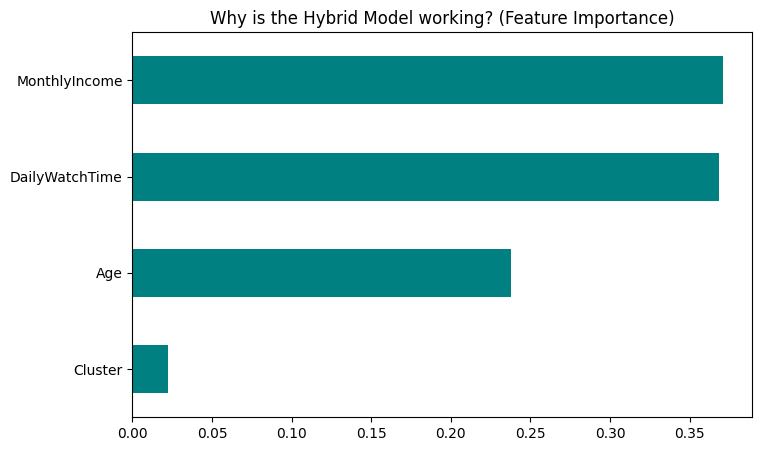

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# 1. Setup Data (Synthetic Netflix Dataset)
np.random.seed(42)
n_samples = 1000
data = {
    'Age': np.random.randint(18, 70, n_samples),
    'MonthlyIncome': np.random.randint(2000, 10000, n_samples),
    'DailyWatchTime': np.random.uniform(0.5, 10, n_samples),
    'Churn': np.random.choice([0, 1], n_samples, p=[0.8, 0.2])
}
df = pd.DataFrame(data)

# 2. Unsupervised Learning: K-Means Clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Age', 'MonthlyIncome', 'DailyWatchTime']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# --- VISUALIZATION 1: 3D Cluster Plot (Viewer Personas) ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'blue', 'green']

for i in range(3):
    clustered_data = df[df['Cluster'] == i]
    ax.scatter(clustered_data['Age'], clustered_data['MonthlyIncome'],
               clustered_data['DailyWatchTime'], c=colors[i], label=f'Cluster {i}', s=30)

ax.set_xlabel('Age')
ax.set_ylabel('Monthly Income')
ax.set_zlabel('Daily Watch Time')
plt.title('Unsupervised Learning: Identifying Viewer Personas')
plt.legend()
plt.show()

# 3. Supervised Learning: Random Forest Churn Prediction
X = df[['Age', 'MonthlyIncome', 'DailyWatchTime', 'Cluster']]
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# --- VISUALIZATION 2: Confusion Matrix (Churn Accuracy) ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Supervised Learning: Churn Prediction Accuracy')
plt.show()

# --- VISUALIZATION 3: Feature Importance ---
plt.figure(figsize=(8, 5))
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Why is the Hybrid Model working? (Feature Importance)')
plt.show()